In [12]:
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

In [10]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.parent
RESULTS_FILE = PROJECT_ROOT / "outputs" / "mlp_results.csv"
LOSS_FILE = PROJECT_ROOT / "outputs" / "mlp_loss.csv"
LOSS_IMAGE = PROJECT_ROOT / "outputs" / "plots" / "mlp_loss.png"
HIST_IMAGE = PROJECT_ROOT / "outputs" / "plots" / "mlp_hist.png"
CONFUSION_MATRIX_IMAGE = PROJECT_ROOT / "outputs" / "plots" / "mlp_confusion_matrix.png"
ROC_CURVE_IMAGE = PROJECT_ROOT / "outputs" / "plots" / "mlp_roc_curve.png"
PR_CURVE_IMAGE = PROJECT_ROOT / "outputs" / "plots" / "mlp_precision_recall.png"

In [5]:
results = pd.read_csv(RESULTS_FILE)
loss = pd.read_csv(LOSS_FILE)

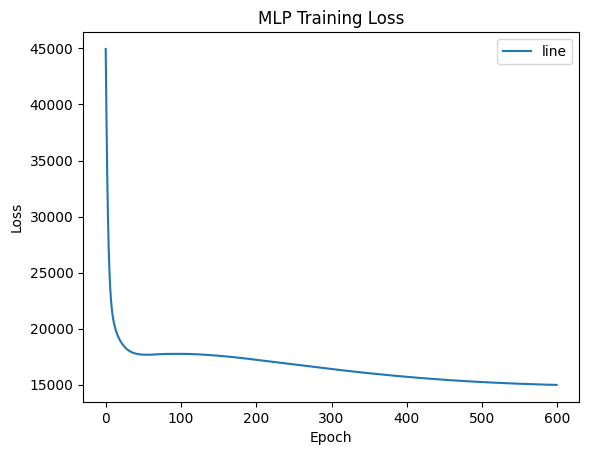

In [6]:
plt.plot(loss['epoch'], loss['loss'], label="line")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.legend()
plt.savefig(LOSS_IMAGE)
plt.show()

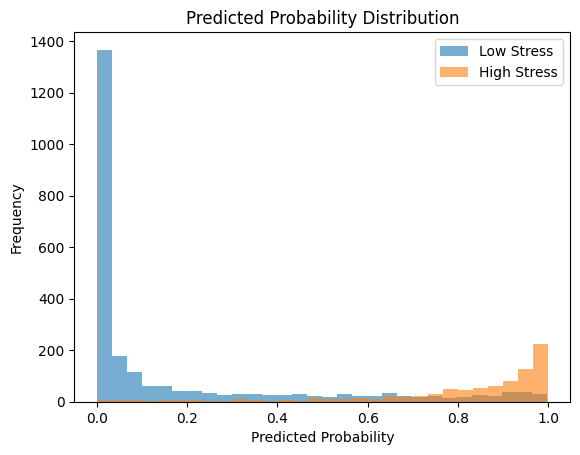

In [7]:
plt.hist(results[results['true_label']==0]['pred_prob'], bins=30, alpha=0.6, label='Low Stress')
plt.hist(results[results['true_label']==1]['pred_prob'], bins=30, alpha=0.6, label='High Stress')
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.legend()
plt.savefig(HIST_IMAGE)
plt.title("Predicted Probability Distribution")
plt.show()

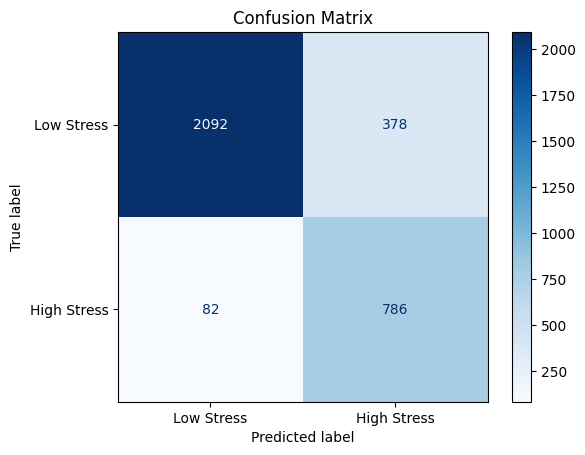

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    results['true_label'],
    results['pred_label'],
    display_labels=['Low Stress', 'High Stress'],
)
plt.title('Confusion Matrix')
plt.savefig(CONFUSION_MATRIX_IMAGE)
plt.show()


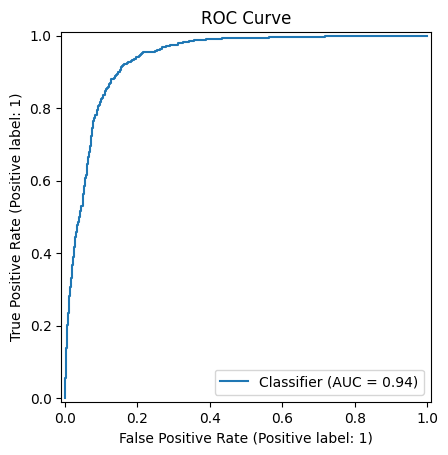

In [13]:
RocCurveDisplay.from_predictions(
    results['true_label'], 
    results['pred_prob']
    )
plt.title('ROC Curve')
plt.savefig(ROC_CURVE_IMAGE)
plt.show()

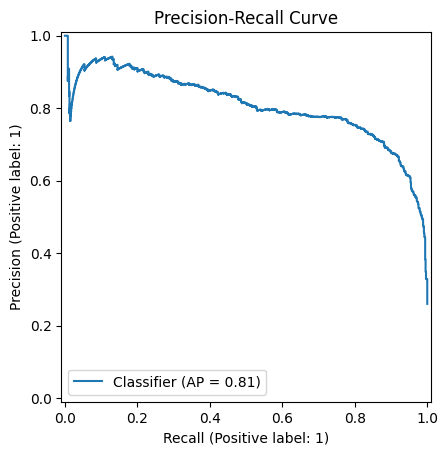

In [14]:
PrecisionRecallDisplay.from_predictions(
    results['true_label'], 
    results['pred_prob']
    )
plt.title('Precision-Recall Curve')
plt.savefig(PR_CURVE_IMAGE)
plt.show()